# Rearrangement Testing

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*3
X0, Y0, WIDTH, HEIGHT = 170, 280, 150, 150
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## MOT Check

MOT detected at (x, y): (932, 562)


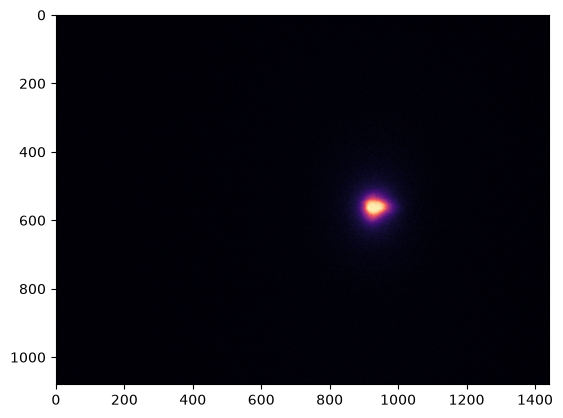

In [15]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 35000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

## Generate Tweezer Array

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


In [5]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.58e-05 | Uniformity: 51.52% | Min/Max ratio: 0.064
Iteration 010 | Mean-Squared Error: 9.75e-08 | Uniformity: 83.01% | Min/Max ratio: 0.495
Iteration 020 | Mean-Squared Error: 3.49e-08 | Uniformity: 83.29% | Min/Max ratio: 0.520
Iteration 030 | Mean-Squared Error: 4.57e-08 | Uniformity: 83.59% | Min/Max ratio: 0.530
Iteration 040 | Mean-Squared Error: 1.20e-08 | Uniformity: 83.62% | Min/Max ratio: 0.527
Iteration 050 | Mean-Squared Error: 1.16e-08 | Uniformity: 83.64% | Min/Max ratio: 0.532
Iteration 060 | Mean-Squared Error: 8.80e-10 | Uniformity: 83.61% | Min/Max ratio: 0.529
Iteration 070 | Mean-Squared Error: 1.67e-10 | Uniformity: 83.57% | Min/Max ratio: 0.529
Iteration 080 | Mean-Squared Error: 5.84e-11 | Uniformity: 83.57% | Min/Max ratio: 0.529
Iteration 090 | Mean-Squared Error: 2.79e-11 | Uniformity: 83.57% | Min/Max ratio: 0.529
Itera

In [6]:
W2 = np.ones((6,6))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 6x6
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.17e-04 | Uniformity: 56.42% | Min/Max ratio: 0.173
Iteration 010 | Mean-Squared Error: 2.16e-07 | Uniformity: 89.23% | Min/Max ratio: 0.660
Iteration 020 | Mean-Squared Error: 4.68e-07 | Uniformity: 90.43% | Min/Max ratio: 0.680
Iteration 030 | Mean-Squared Error: 1.57e-08 | Uniformity: 90.36% | Min/Max ratio: 0.694
Iteration 040 | Mean-Squared Error: 8.79e-09 | Uniformity: 90.20% | Min/Max ratio: 0.690
Iteration 050 | Mean-Squared Error: 2.18e-08 | Uniformity: 90.21% | Min/Max ratio: 0.691
Iteration 060 | Mean-Squared Error: 1.81e-08 | Uniformity: 90.12% | Min/Max ratio: 0.690
Iteration 070 | Mean-Squared Error: 2.35e-08 | Uniformity: 89.99% | Min/Max ratio: 0.686
Iteration 080 | Mean-Squared Error: 5.30e-08 | Uniformity: 89.91% | Min/Max ratio: 0.682
Iteration 090 | Mean-Squared Error: 2.75e-08 | Uniformity: 90.04% | Min/Max ratio: 0.684
Iterati

In [7]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Initial Array

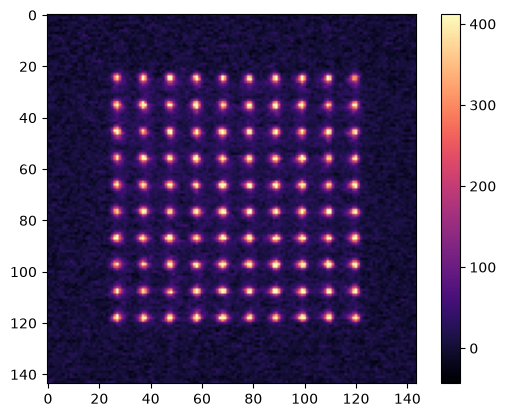

In [9]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


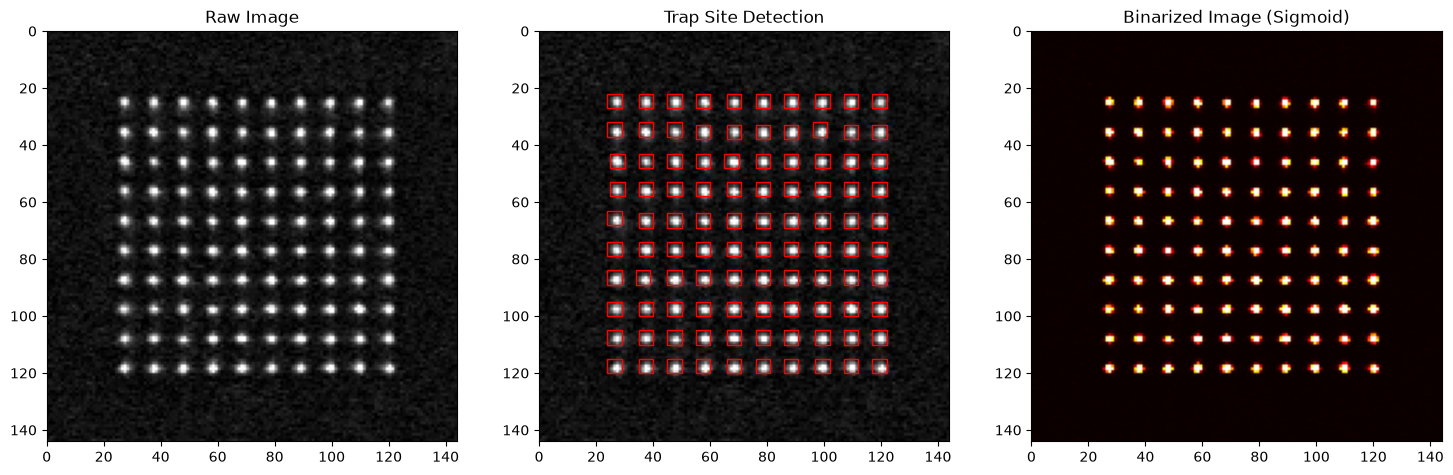

Trap (0, 0) Loading Probability : 51.00 %
Trap (0, 1) Loading Probability : 55.00 %
Trap (0, 2) Loading Probability : 56.00 %
Trap (0, 3) Loading Probability : 57.00 %
Trap (0, 4) Loading Probability : 53.00 %
Trap (0, 5) Loading Probability : 50.00 %
Trap (0, 6) Loading Probability : 61.00 %
Trap (0, 7) Loading Probability : 52.00 %
Trap (0, 8) Loading Probability : 56.00 %
Trap (0, 9) Loading Probability : 50.00 %
Trap (1, 0) Loading Probability : 64.00 %
Trap (1, 1) Loading Probability : 60.00 %
Trap (1, 2) Loading Probability : 53.00 %
Trap (1, 3) Loading Probability : 60.00 %
Trap (1, 4) Loading Probability : 40.00 %
Trap (1, 5) Loading Probability : 54.00 %
Trap (1, 6) Loading Probability : 61.00 %
Trap (1, 7) Loading Probability : 55.00 %
Trap (1, 8) Loading Probability : 44.00 %
Trap (1, 9) Loading Probability : 52.00 %
Trap (2, 0) Loading Probability : 62.00 %
Trap (2, 1) Loading Probability : 48.00 %
Trap (2, 2) Loading Probability : 56.00 %
Trap (2, 3) Loading Probability : 

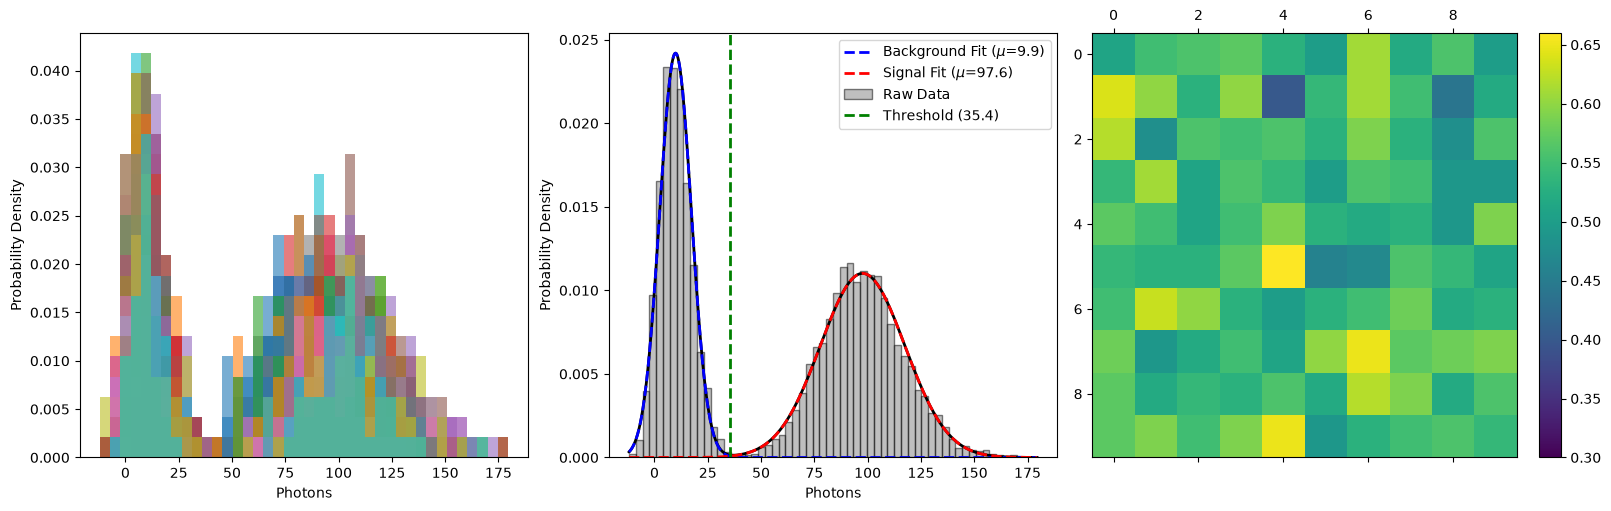

In [10]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)

## Baseline Survival

In [106]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

Trap (0, 0) Loading Probability : 48.00 %
Trap (0, 1) Loading Probability : 50.50 %
Trap (0, 2) Loading Probability : 52.00 %
Trap (0, 3) Loading Probability : 45.00 %
Trap (0, 4) Loading Probability : 56.50 %
Trap (0, 5) Loading Probability : 46.00 %
Trap (0, 6) Loading Probability : 45.00 %
Trap (0, 7) Loading Probability : 55.50 %
Trap (0, 8) Loading Probability : 54.00 %
Trap (0, 9) Loading Probability : 52.00 %
Trap (1, 0) Loading Probability : 50.00 %
Trap (1, 1) Loading Probability : 49.00 %
Trap (1, 2) Loading Probability : 52.00 %
Trap (1, 3) Loading Probability : 52.50 %
Trap (1, 4) Loading Probability : 58.50 %
Trap (1, 5) Loading Probability : 46.00 %
Trap (1, 6) Loading Probability : 49.00 %
Trap (1, 7) Loading Probability : 52.00 %
Trap (1, 8) Loading Probability : 52.00 %
Trap (1, 9) Loading Probability : 53.00 %
Trap (2, 0) Loading Probability : 50.50 %
Trap (2, 1) Loading Probability : 52.00 %
Trap (2, 2) Loading Probability : 54.00 %
Trap (2, 3) Loading Probability : 

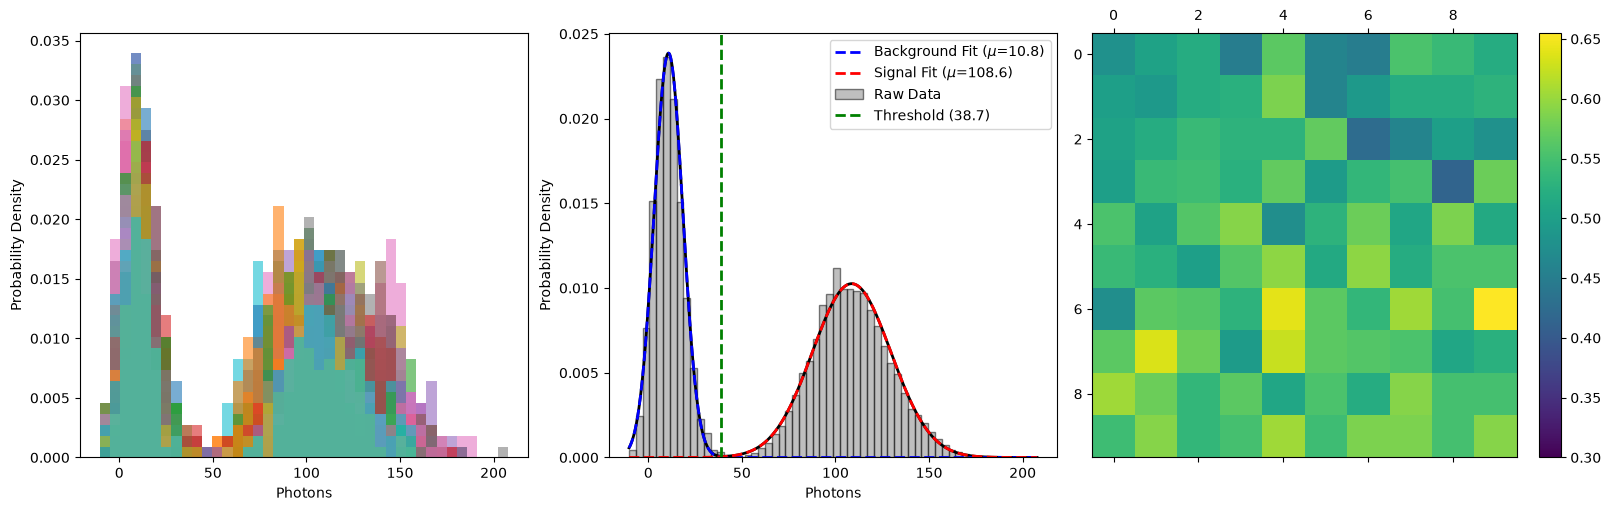

In [107]:
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
out_ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

## Rearrangement Init

In [11]:
threshold_count = an.convert_photons_to_counts(threshold_1) * 1.1
threshold_count

np.float64(5047.375430755015)

In [12]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
from pytweezer.drivers.arduino import ArduinoPulser

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=1.0, fps=1/(1e-6), threshold=threshold_count,
    grid_positions=grid_positions_1, profile="linear", window_size=window, feature_size=feature_size
)

Rearrangement node initialised.


## Rearrangement Exp

In [13]:
import time

# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [14]:
N_iterations = 200  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": 3.3, "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 200
Reset-image acquisition failed; returning zeros.
Rearrangement complete: 11 frames, 48.9995ms total (occupancy 6.9995ms, calculation+upload 42.0001ms).
Images acquired from rearrangement node.
Empty image received at iteration 1. Discarding...
Running experiment iteration 2 / 200
Rearrangement complete: 11 frames, 11.9998ms total (occupancy 0.9999ms, calculation+upload 10.9999ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 200
Rearrangement complete: 12 frames, 13.7353ms total (occupancy 0.0000ms, calculation+upload 13.7353ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 200
Rearrangement complete: 12 frames, 11.9944ms total (occupancy 0.0000ms, calculation+upload 11.9944ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 200
Rearrangement complete: 10 frames, 11.1628ms total (occupancy 1.0035ms, calculation+upload 10.1593ms).
Images acquired from rearrangement n

In [20]:
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.4f} ms/frame")

Average calculation and upload speed = 1.0514 ms/frame


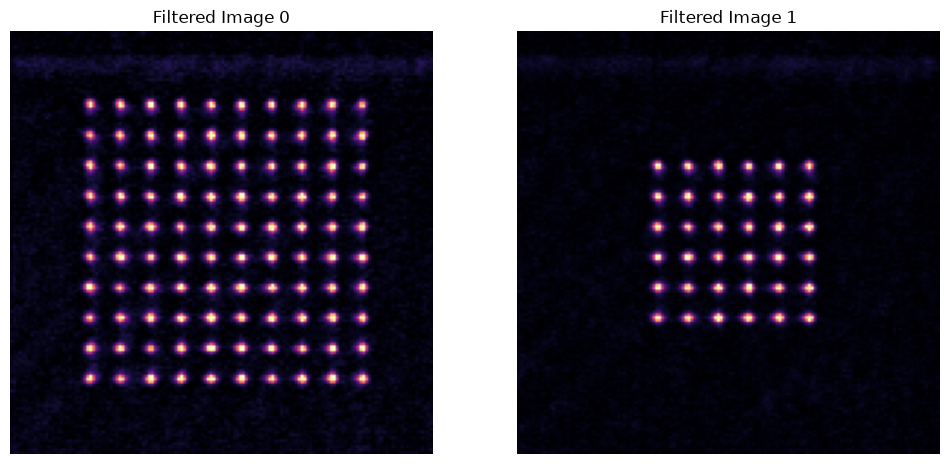

In [15]:
tot_imgs = np.array(imgs_software)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

# Plot imgs0_mean_filtered and imgs1_mean_filtered side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

Looking for trap sites...
10x10 array detected.


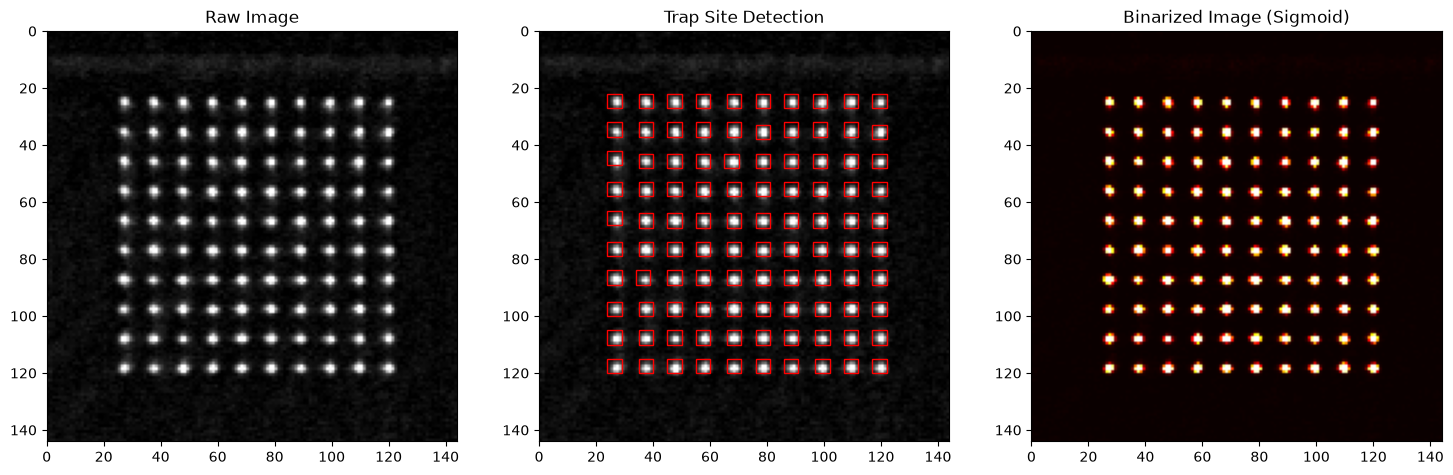

Trap (0, 0) Loading Probability : 56.78 %
Trap (0, 1) Loading Probability : 59.30 %
Trap (0, 2) Loading Probability : 54.27 %
Trap (0, 3) Loading Probability : 58.79 %
Trap (0, 4) Loading Probability : 52.76 %
Trap (0, 5) Loading Probability : 57.79 %
Trap (0, 6) Loading Probability : 56.78 %
Trap (0, 7) Loading Probability : 56.78 %
Trap (0, 8) Loading Probability : 58.29 %
Trap (0, 9) Loading Probability : 49.75 %
Trap (1, 0) Loading Probability : 53.77 %
Trap (1, 1) Loading Probability : 54.27 %
Trap (1, 2) Loading Probability : 62.31 %
Trap (1, 3) Loading Probability : 49.25 %
Trap (1, 4) Loading Probability : 56.78 %
Trap (1, 5) Loading Probability : 58.29 %
Trap (1, 6) Loading Probability : 57.79 %
Trap (1, 7) Loading Probability : 51.26 %
Trap (1, 8) Loading Probability : 58.79 %
Trap (1, 9) Loading Probability : 58.79 %
Trap (2, 0) Loading Probability : 54.77 %
Trap (2, 1) Loading Probability : 53.77 %
Trap (2, 2) Loading Probability : 57.29 %
Trap (2, 3) Loading Probability : 

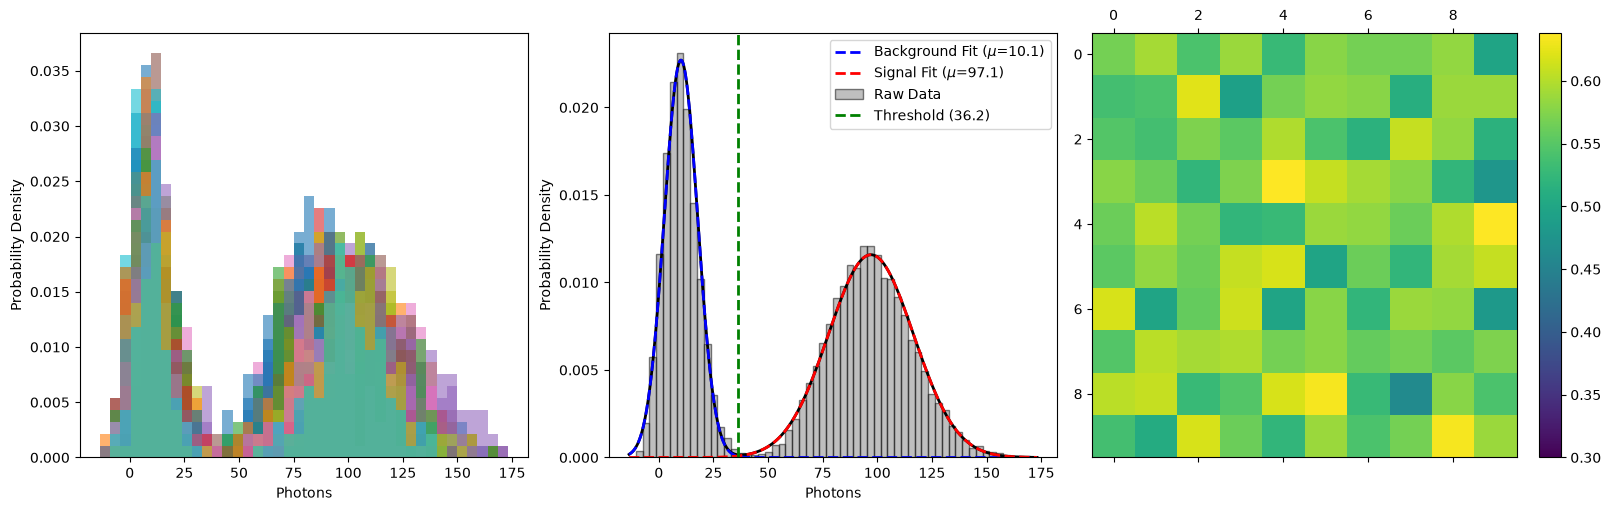

In [16]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

grid_positions_1, detection_threshold = an.detect_trap_sites(imgs0_mean_filtered, array_shape_1, detection_step=200)
an.visualize_results(imgs0_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)

Looking for trap sites...
6x6 array detected.


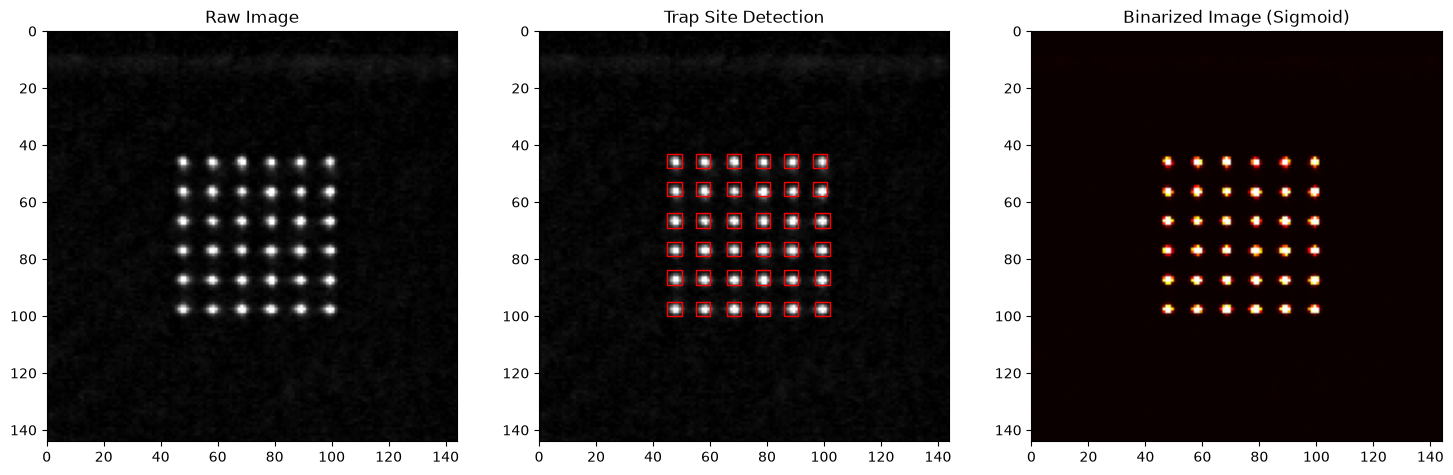

Trap (0, 0) Loading Probability : 93.97 %
Trap (0, 1) Loading Probability : 96.98 %
Trap (0, 2) Loading Probability : 96.98 %
Trap (0, 3) Loading Probability : 96.98 %
Trap (0, 4) Loading Probability : 97.49 %
Trap (0, 5) Loading Probability : 95.48 %
Trap (1, 0) Loading Probability : 94.97 %
Trap (1, 1) Loading Probability : 96.48 %
Trap (1, 2) Loading Probability : 95.48 %
Trap (1, 3) Loading Probability : 95.48 %
Trap (1, 4) Loading Probability : 96.98 %
Trap (1, 5) Loading Probability : 98.49 %
Trap (2, 0) Loading Probability : 96.98 %
Trap (2, 1) Loading Probability : 95.98 %
Trap (2, 2) Loading Probability : 94.97 %
Trap (2, 3) Loading Probability : 96.48 %
Trap (2, 4) Loading Probability : 99.50 %
Trap (2, 5) Loading Probability : 96.98 %
Trap (3, 0) Loading Probability : 95.98 %
Trap (3, 1) Loading Probability : 96.98 %
Trap (3, 2) Loading Probability : 96.98 %
Trap (3, 3) Loading Probability : 95.98 %
Trap (3, 4) Loading Probability : 97.49 %
Trap (3, 5) Loading Probability : 

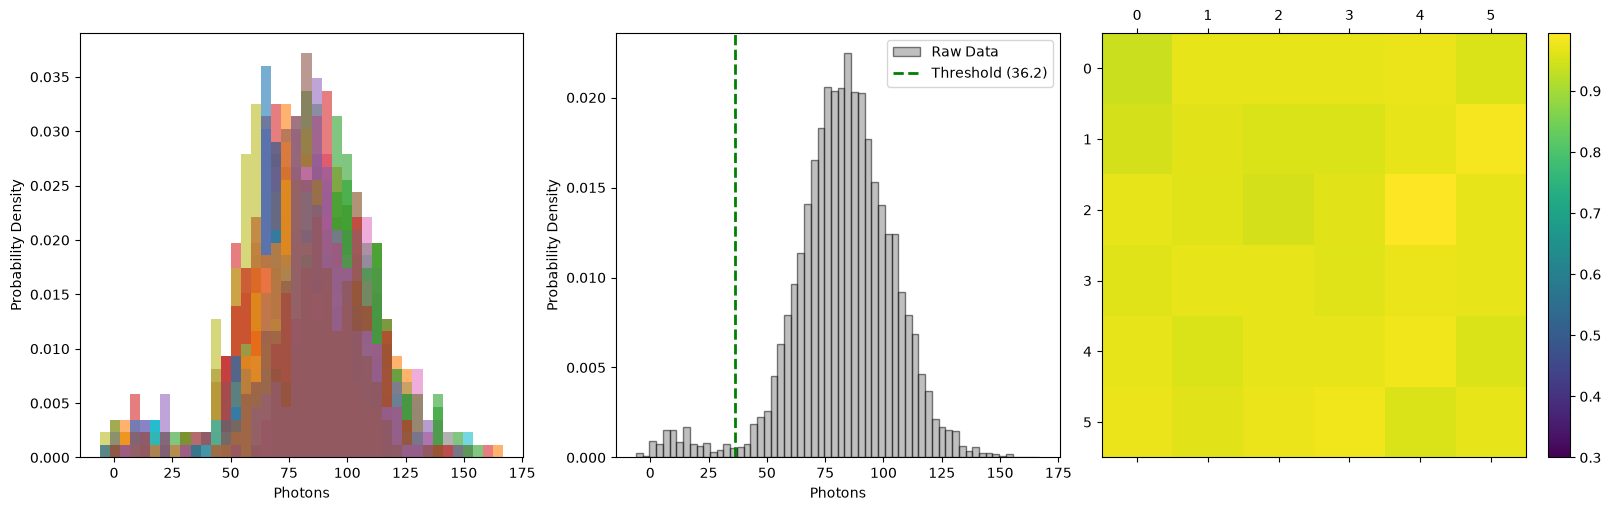

In [17]:
array_shape_2 = [6, 6]
window = 5
feature_size = 10

grid_positions_2, detection_threshold = an.detect_trap_sites(imgs1_mean_filtered, array_shape_2, detection_step=200)
an.visualize_results(imgs1_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold_2, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_1, window_size=window, binning=60)

In [20]:
loading_probabilities.mean() / 0.97

np.float64(0.9962469852124309)

In [ ]:
year, month, day = time.localtime().tm_year, time.localtime().tm_mon, time.localtime().tm_mday
data_dir = r"C:\Users\tweez\Box\Working folder\caftweezers"
year

---

### Preflight checks
Offline verification of the rearrangement path — no MOT shot, no trigger, no atoms.
Run this after `initialise` and before either Option A or Option B.

It exercises occupancy extraction end to end on a synthetic frame, which is where
every failure in this pipeline has surfaced so far: stale code in the kernel, a frame
dtype the compiled extension rejects, and ROI/grid mismatches. All of those raise
*inside* `arm_rearrangement`, i.e. only after a shot has already been fired.

In [21]:
import time
import pytweezer.coordinators.rearrangement as rr

problems, notes = [], []

# 1. Which occupancy implementation is actually live? The compiled path is opt-in
#    via USE_SUM_CPP and falls back silently if the extension fails to import, so
#    the only way to know what will run is to ask.
_morph, _summer = rr._morph_cpp(), rr._sum_cpp()
notes.append(f"USE_SUM_CPP={rr.USE_SUM_CPP}  ->  tophat={'C++' if _morph else 'numpy'}, "
             f"pixel-sum={'C++' if _summer else 'numpy'}")

# 2. Is the code in memory current? Editing rearrangement.py does not affect a
#    running kernel, and importlib.reload cannot rebind methods already attached to
#    a live coordinator. Fingerprint the bound method rather than trusting mtimes.
_names = type(coordinator)._extract_occupancy.__code__.co_names
if "Morphological_top_hat_cpp" in _names:
    problems.append("stale _extract_occupancy in memory (pre-fix version) — restart the kernel")

# 3. Coordinator state, and does the grid agree with the array and the ROI?
if not coordinator._initialised:
    problems.append("coordinator.initialise() has not been run")
else:
    _shape = coordinator._state["terms1"][4]
    _n_sites = int(np.prod(_shape))
    if len(grid_positions_1) != _n_sites:
        problems.append(f"grid_positions_1 has {len(grid_positions_1)} sites but terms1 array_shape "
                        f"{list(_shape)} implies {_n_sites}")
    _ys = [y for (y, x) in grid_positions_1.values()]
    _xs = [x for (y, x) in grid_positions_1.values()]
    if max(_ys) >= HEIGHT or max(_xs) >= WIDTH:
        problems.append(f"grid_positions_1 run to (y={max(_ys)}, x={max(_xs)}) but the ROI is "
                        f"{WIDTH}x{HEIGHT} — were the sites detected on a full frame?")
    else:
        notes.append(f"grid: {len(grid_positions_1)} sites, max (y,x)=({max(_ys)},{max(_xs)}), "
                     f"inside the {WIDTH}x{HEIGHT} ROI")
    if not np.isfinite(threshold_count) or threshold_count <= 0:
        problems.append(f"threshold_count is {threshold_count}")
    else:
        notes.append(f"threshold_count = {threshold_count:.1f}")

# 4. What does the camera actually hand back? A frame that is not native '<u2'
#    either skips the compiled path or gets rejected by it at the pybind boundary.
try:
    _frame = np.asarray(imgs1[0])
    notes.append(f"camera frame: {type(imgs1[0]).__name__}, dtype={_frame.dtype.str}, "
                 f"shape={_frame.shape}")
    if _frame.dtype != np.uint16:
        notes.append("   ^ not native uint16 — the compiled occupancy path will be skipped")
    if _frame.shape != (HEIGHT, WIDTH):
        problems.append(f"frame shape {_frame.shape} != ROI ({HEIGHT}, {WIDTH})")
except NameError:
    notes.append("no frames captured yet — run the baseline scan to check the frame dtype")

# 5. Dry-run occupancy extraction on a synthetic ROI-sized uint16 frame with every
#    site lit. A zero threshold means all sites must come back occupied; anything
#    else points at the grid, not the extraction.
if coordinator._initialised:
    try:
        _probe = np.zeros((HEIGHT, WIDTH), dtype=np.uint16)
        for (_i, _j), (_y, _x) in grid_positions_1.items():
            _probe[max(_y - 2, 0):_y + 3, max(_x - 2, 0):_x + 3] = 1000
        _t0 = time.perf_counter()
        _mask = coordinator._extract_occupancy(_probe, coordinator._state["terms1"][4], 0)
        _dt = (time.perf_counter() - _t0) * 1e3
        notes.append(f"occupancy dry-run: {int(_mask.sum())}/{_mask.size} sites over a zero "
                     f"threshold in {_dt:.2f} ms")
        if int(_mask.sum()) != _mask.size:
            problems.append(f"dry-run lit every site but only {int(_mask.sum())}/{_mask.size} came "
                            f"back occupied — grid_positions_1 and the array shape disagree")
    except Exception as _exc:
        problems.append(f"occupancy dry-run failed: {type(_exc).__name__}: {_exc}")

# 6. Does the precomputed initial mask match the panel?
try:
    _dims = slm.get_dimensions()
    notes.append(f"SLM {_dims['width']}x{_dims['height']} @ {_dims['depth']}-bit")
    if coordinator._initialised:
        _init = coordinator._state["pm_init_uint8"]
        if _init.shape != (_dims["height"], _dims["width"]):
            problems.append(f"init mask {_init.shape} != panel "
                            f"({_dims['height']}, {_dims['width']})")
except Exception as _exc:
    notes.append(f"SLM dimensions unavailable: {_exc}")

print("\n".join("  - " + n for n in notes))
if problems:
    print("\nPREFLIGHT FAILED — do not fire a shot:")
    print("\n".join("  ! " + p for p in problems))
else:
    print("\nPREFLIGHT OK — safe to run Option A or Option B")

  - USE_SUM_CPP=True  ->  tophat=C++, pixel-sum=C++
  - grid: 100 sites, max (y,x)=(117,119), inside the 150x150 ROI
  - threshold_count = 5047.4
  - camera frame: ndarray, dtype=<u2, shape=(144, 144)
  - occupancy dry-run: 100/100 sites over a zero threshold in 0.55 ms
  - SLM 1024x1024 @ 8-bit

PREFLIGHT FAILED — do not fire a shot:
  ! frame shape (144, 144) != ROI (150, 150)


### Option A — fast software pipeline
Per-frame `update_mask` writes, pipelined so GPU generation of frame *n+1* overlaps
the upload of frame *n*. No hardware trigger needed.

In [14]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
from pytweezer.drivers.arduino import ArduinoPulser

coordinator = Rearrangement({"camera": hamcam, "slm": slm}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=1.0, fps=1/(1e-6), threshold=threshold_count,
    grid_positions=grid_positions_1, roi=[X0, Y0, WIDTH, HEIGHT], profile="linear"
)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
Phasemask generator initialised.
Camera configured for rearrangement (roi=%s). [110, 220, 256, 256]
Rearrangement node initialised.


In [15]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [16]:
N_iterations = 5  # adjust before running
imgs_software = []
err_indices = []
timings_software = []   # kept separate from Option B so the two can be compared

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
    timings_software.append(timings)

print(f"Average total rearrangement time = {np.mean([t['total_rearrangement_s'] for t in timings_software])*1000:.2f} ms")

Running experiment iteration 1 / 5
uint16


RuntimeError: unsupported dtype: expected uint8, uint16, float32 or float64

### Option B — preload + hardware trigger
Preloads the whole sequence into the SLM's on-board memory (still pipelined against
GPU generation), then clocks it out with an external trigger — no per-frame software
write on the hot path. Uses the `linear` delivery profile (fewer frames than
`minimum_jerk` for the same `d0`) since it pairs naturally with the trigger path.
Requires the trigger pulser wired to the SLM's external trigger input and a
1024x1024 board on firmware >= 2.4.

In [18]:
arduino = ArduinoPulser('COM5')
startup_message = arduino.connect()
print(f"Arduino connected: {startup_message}")

Arduino connected: Listening for Python...


In [19]:
# Option B preflight — board capability and pulser, before any shot.
# Set True to physically exercise preload + trigger. It preloads the *initial* mask
# into two frame slots and clocks one pulse, so the panel shows what it already
# shows — but it does drive the board, so leave it off during a running sequence.
RUN_TRIGGER_DRYRUN = False

b_problems, b_notes = [], []

# start_auto_increment is 1024x1024 / firmware >= 2.4 only. The firmware revision
# is not exposed by the driver, so geometry is as far as this check can go — a
# 2.3 board passes here and fails at start_auto_increment().
try:
    _dims = slm.get_dimensions()
    if (_dims["width"], _dims["height"]) != (1024, 1024):
        b_problems.append(f"preload+trigger needs a 1024x1024 board; this is "
                          f"{_dims['width']}x{_dims['height']}")
    else:
        b_notes.append(f"SLM {_dims['width']}x{_dims['height']} (firmware rev not queryable — "
                       f"if start_auto_increment fails, suspect firmware < 2.4)")
    for _m in ("preload_image", "set_wait_for_trigger", "start_auto_increment",
               "stop_auto_increment"):
        if not hasattr(slm, _m):
            b_problems.append(f"SLM driver has no {_m}()")
except Exception as _exc:
    b_problems.append(f"could not query the SLM: {_exc}")

# Pulser
if "arduino" not in dir() or arduino is None:
    b_problems.append("arduino pulser not created — run the ArduinoPulser cell above")
elif not hasattr(arduino, "send_pulses"):
    b_problems.append(f"{type(arduino).__name__} has no send_pulses(n, period_us=...)")
else:
    b_notes.append(f"pulser {type(arduino).__name__} ready")

if RUN_TRIGGER_DRYRUN and not b_problems:
    try:
        _mask0 = coordinator._state["pm_init_uint8"]
        slm.set_wait_for_trigger(False)          # must be off while preloading
        for _k in range(2):
            slm.preload_image(_mask0, _k)
        slm.set_wait_for_trigger(True)
        slm.start_auto_increment(2)
        try:
            arduino.send_pulses(1, period_us=700)
        finally:
            slm.stop_auto_increment()
            slm.set_wait_for_trigger(False)
        b_notes.append("trigger dry-run OK: 2 frames preloaded, 1 pulse clocked")
    except Exception as _exc:
        b_problems.append(f"trigger dry-run failed: {type(_exc).__name__}: {_exc}")

print("\n".join("  - " + n for n in b_notes))
if b_problems:
    print("\nOPTION B PREFLIGHT FAILED:")
    print("\n".join("  ! " + p for p in b_problems))
else:
    print("\nOPTION B PREFLIGHT OK" + ("" if RUN_TRIGGER_DRYRUN else
          " (set RUN_TRIGGER_DRYRUN = True to actually exercise the trigger path)"))

  - SLM 1024x1024 (firmware rev not queryable — if start_auto_increment fails, suspect firmware < 2.4)
  - pulser ArduinoPulser ready

OPTION B PREFLIGHT OK (set RUN_TRIGGER_DRYRUN = True to actually exercise the trigger path)


In [20]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [21]:
N_iterations = 10  # adjust before running
imgs_trigger = []
err_indices = []
timings_trigger = []   # kept separate from Option A so the two can be compared

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(
        coordinator.arm_rearrangement_preload_trigger, arduino, period_us=700, profile="linear", restore_initial_array=True
    ))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_trigger.append([img0, img1])
    timings_trigger.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_trigger])
mean_calc_preload_time_ms = np.mean([t['calculation_and_preload_ms'] for t in timings_trigger])
mean_hardware_trigger_time_ms = np.mean([t['hardware_trigger_upload_ms'] for t in timings_trigger])
mean_nframes = np.mean([t['n_frames'] for t in timings_trigger])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_preload_speed = mean_calc_preload_time_ms / mean_nframes
mean_hardware_trigger_speed = mean_hardware_trigger_time_ms / mean_nframes

print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and preload speed = {mean_calc_preload_speed:.2f} ms/frame")
print(f"Average hardware trigger speed = {mean_hardware_trigger_speed:.2f} ms/frame")

Running experiment iteration 1 / 10


RuntimeError: unsupported dtype: expected uint8, uint16, float32 or float64

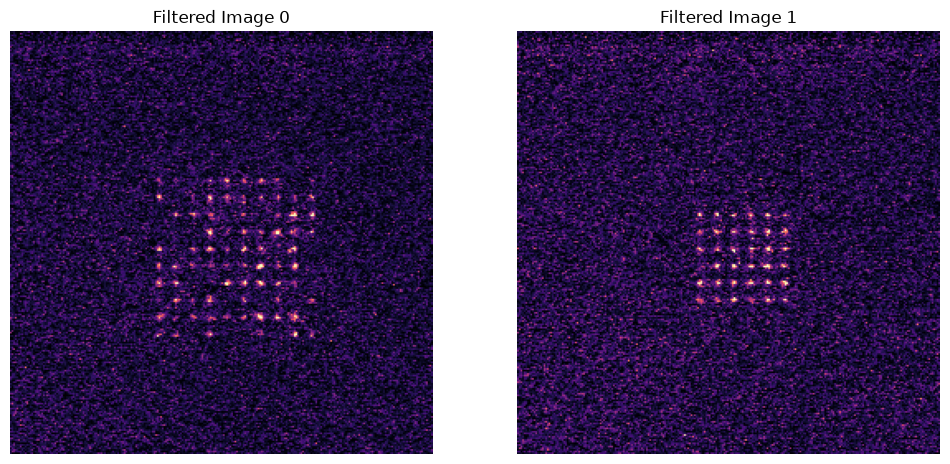

In [24]:
tot_imgs = np.array(imgs_trigger)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

# Plot imgs0_mean_filtered and imgs1_mean_filtered side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

### Timing — Option A vs Option B
Both methods return the **same four keys with different meanings**, so the dicts must
not be diffed blindly:

| key | Option A (software pipeline) | Option B (preload + trigger) |
|---|---|---|
| `occupancy_extraction_s` | occupancy extraction | same |
| `rearrangement_sequence_generation_s` | GPU generation **and** upload — one pipelined span | GPU generation + on-board preload |
| `slm_upload_s` | *the same span again*, not a separate measurement | hardware-triggered playback |
| `total_rearrangement_s` | image → sequence → reset image | same, plus the trigger phase |

Option A reports one span under two keys deliberately: generation and upload overlap,
so splitting them would only show where the pipeline happened to stall. Option B's two
phases are genuinely sequential and separately meaningful.

---

In [22]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.


---

In [1]:
# check for cpp modules

import time
import pytweezer.coordinators.rearrangement as rr

problems, notes = [], []

# 1. Which occupancy implementation is actually live? The compiled path is opt-in
#    via USE_SUM_CPP and falls back silently if the extension fails to import, so
#    the only way to know what will run is to ask.
_morph, _summer = rr._morph_cpp(), rr._sum_cpp()
notes.append(f"USE_SUM_CPP={rr.USE_SUM_CPP}  ->  tophat={'C++' if _morph else 'numpy'}, "
             f"pixel-sum={'C++' if _summer else 'numpy'}")

print("\n".join("  - " + n for n in notes))

  - USE_SUM_CPP=True  ->  tophat=C++, pixel-sum=C++
